# CIFAR-10 Image Classifier with Transfer Learning

**Goal:** Train a CNN on CIFAR-10 that achieves **>80% test accuracy** using a frozen, pretrained MobileNetV2 backbone (ImageNet weights) with a small classification head, using data augmentation (flips + random crops).


**Tech used:** TensorFlow/Keras, CNN, Transfer Learning, Data Augmentation

## 1. Setup - Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)


TensorFlow version: 2.21.0


## 2. Load CIFAR-10

The official CIFAR-10 dataset is loaded from a local cache instead of using
automatic online download, ensuring reproducible execution without dependency
on external network availability.

The dataset consists of 60,000 RGB images of size 32×32 distributed across
10 object classes, with 50,000 images used for training and 10,000 images
used for testing.

In [2]:
import os
import pickle

# Folder containing the extracted official CIFAR-10 batches
# (batches.meta, data_batch_1..5, test_batch, readme.html)
import os

CIFAR10_LOCAL_DIR = os.path.expanduser(
    "~/.keras/datasets/cifar-10-batches-py"
)

def load_cifar10_batch(file_path):
    """Load a single CIFAR-10 batch file (official pickled format)."""
    with open(file_path, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    # Official format: 10000 x 3072 (3*32*32), channel-first -> reshape then transpose to HWC
    data = batch[b'data'].reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.array(batch[b'labels'])
    return data, labels

def load_cifar10_local(data_dir):
    """Reconstruct the same (x_train, y_train), (x_test, y_test) structure that
    keras.datasets.cifar10.load_data() would normally return."""
    train_data, train_labels = [], []
    for i in range(1, 6):
        data, labels = load_cifar10_batch(os.path.join(data_dir, f'data_batch_{i}'))
        train_data.append(data)
        train_labels.append(labels)
    x_train_full = np.concatenate(train_data)
    y_train_full = np.concatenate(train_labels)

    x_test, y_test = load_cifar10_batch(os.path.join(data_dir, 'test_batch'))
    return (x_train_full, y_train_full), (x_test, y_test)

(x_train_full, y_train_full), (x_test, y_test) = load_cifar10_local(CIFAR10_LOCAL_DIR)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Keep images as float32 WITHOUT rescaling to [0,1] here.
# MobileNetV2's preprocess_input (used inside the model) expects raw pixel
# values in the 0-255 range and rescales them to [-1, 1] itself.
x_train_full = x_train_full.astype('float32')
x_test = x_test.astype('float32')

print("Full train shape:", x_train_full.shape)
print("Test shape:", x_test.shape)


Full train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 3. Train / Validation Split

We hold out 5,000 images from the training set for validation, keeping 45,000 for training.


In [3]:
VAL_SIZE = 5000

x_val = x_train_full[-VAL_SIZE:]
y_val = y_train_full[-VAL_SIZE:]
x_train = x_train_full[:-VAL_SIZE]
y_train = y_train_full[:-VAL_SIZE]

print("Train:", x_train.shape, "Val:", x_val.shape, "Test:", x_test.shape)


Train: (45000, 32, 32, 3) Val: (5000, 32, 32, 3) Test: (10000, 32, 32, 3)


## 4. Build tf.data Pipelines

We batch and prefetch the raw (unaugmented) images here. Augmentation and
preprocessing are built directly into the model in the next step, so the
exact same pipeline can be reused for training, validation, and inference.


In [4]:
BATCH_SIZE = 128

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(10000, seed=42).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val))
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


W0000 00:00:1783357053.326130   39658 cpu_allocator_impl.cc:82] Allocation of 552960000 exceeds 10% of free system memory.
W0000 00:00:1783357054.287357   39658 cpu_allocator_impl.cc:82] Allocation of 61440000 exceeds 10% of free system memory.
W0000 00:00:1783357054.396497   39658 cpu_allocator_impl.cc:82] Allocation of 122880000 exceeds 10% of free system memory.


## 5. Build the Model

**Pipeline (all inside the Keras model):**
1. Data augmentation: random horizontal flip + random crop (pad 4px, then crop back to 32x32) - a standard CIFAR-10 augmentation recipe. These layers are automatically active only during training.
2. Resize 32x32 -> 96x96 (MobileNetV2 needs a larger input to extract useful features).
3. MobileNetV2 preprocessing (scales pixels to the [-1, 1] range it expects).
4. **Frozen** MobileNetV2 backbone (`include_top=False`, `weights='imagenet'`) as a feature extractor.
5. Small classification head: GlobalAveragePooling -> Dropout -> Dense(128, relu) -> Dropout -> Dense(10, softmax).


In [5]:
IMG_SIZE = 96

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.ZeroPadding2D(padding=4),
    layers.RandomCrop(32, 32),
], name="data_augmentation")

inputs = keras.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)
x = layers.Resizing(IMG_SIZE, IMG_SIZE)(x)
x = layers.Lambda(preprocess_input, output_shape=(IMG_SIZE, IMG_SIZE, 3))(x)

base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # freeze the pretrained backbone

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = keras.Model(inputs, outputs, name="cifar10_mobilenetv2_transfer")
model.summary()


Model: "cifar10_mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Compile the Model

**Hyperparameters:**
- Optimizer: Adam, learning rate = 1e-3 (only the small head is trainable, so a standard Adam LR works well)
- Loss: Sparse Categorical Crossentropy
- Metric: Accuracy
- Epochs: up to 20 (with early stopping)
- Batch size: 128
- Callbacks: EarlyStopping (patience=5, restores best weights) + ReduceLROnPlateau (patience=3)


In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    ),

    keras.callbacks.ModelCheckpoint(
        'best_model1.h5',
        monitor='val_accuracy',
        save_best_only=True
    ),
]


## 7. Train the Model

In [7]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/20


/home/raize/miniforge3/envs/tf/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
W0000 00:00:1783357121.517702   39658 cpu_allocator_impl.cc:82] Allocation of 552960000 exceeds 10% of free system memory.


  1/352 ━━━━━━━━━━━━━━━━━━━━ 36:38 6s/step - accuracy: 0.0703 - loss: 3.2422

W0000 00:00:1783357127.577539   39786 cpu_allocator_impl.cc:82] Allocation of 113246208 exceeds 10% of free system memory.


352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.7355 - loss: 0.7755

...

352/352 ━━━━━━━━━━━━━━━━━━━━ 102s 290ms/step - accuracy: 0.8320 - loss: 0.4733 - val_accuracy: 0.7902 - val_loss: 0.5946 - learning_rate: 0.0010
Epoch 9/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.8376 - loss: 0.4630

352/352 ━━━━━━━━━━━━━━━━━━━━ 104s 296ms/step - accuracy: 0.8376 - loss: 0.4630 - val_accuracy: 0.7996 - val_loss: 0.5809 - learning_rate: 0.0010
Epoch 10/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 102s 289ms/step - accuracy: 0.8429 - loss: 0.4472 - val_accuracy: 0.7948 - val_loss: 0.5825 - learning_rate: 0.0010
Epoch 11/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 268s 762ms/step - accuracy: 0.8408 - loss: 0.4500 - val_accuracy: 0.7952 - val_loss: 0.5814 - learning_rate: 0.0010
Epoch 12/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 109s 310ms/step - accuracy: 0.8470 - loss: 0.4399 - val_accuracy: 0.7968 - val_loss: 0.5877 - learning_rate: 0.0010
Epoch 13/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8524 - loss: 0.4175

352/352 ━━━━━━━━━━━━━━━━━━━━ 613s 2s/step - accuracy: 0.8524 - loss: 0.4175 - val_accuracy: 0.8122 - val_loss: 0.5577 - learning_rate: 5.0000e-04
Epoch 14/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 109s 309ms/step - accuracy: 0.8534 - loss: 0.4149 - val_accuracy: 0.8066 - val_loss: 0.5634 - learning_rate: 5.0000e-04
Epoch 15/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.8530 - loss: 0.4131

352/352 ━━━━━━━━━━━━━━━━━━━━ 96s 274ms/step - accuracy: 0.8530 - loss: 0.4131 - val_accuracy: 0.8152 - val_loss: 0.5417 - learning_rate: 5.0000e-04
Epoch 16/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 97s 276ms/step - accuracy: 0.8584 - loss: 0.4018 - val_accuracy: 0.8140 - val_loss: 0.5458 - learning_rate: 5.0000e-04
Epoch 17/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.8589 - loss: 0.3991

352/352 ━━━━━━━━━━━━━━━━━━━━ 99s 281ms/step - accuracy: 0.8589 - loss: 0.3991 - val_accuracy: 0.8216 - val_loss: 0.5272 - learning_rate: 5.0000e-04
Epoch 18/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 97s 275ms/step - accuracy: 0.8600 - loss: 0.3951 - val_accuracy: 0.8126 - val_loss: 0.5470 - learning_rate: 5.0000e-04
Epoch 19/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 106s 301ms/step - accuracy: 0.8570 - loss: 0.3979 - val_accuracy: 0.8118 - val_loss: 0.5550 - learning_rate: 5.0000e-04
Epoch 20/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 105s 299ms/step - accuracy: 0.8601 - loss: 0.3996 - val_accuracy: 0.8040 - val_loss: 0.5641 - learning_rate: 5.0000e-04


## 8. Training Curves (Accuracy & Loss)

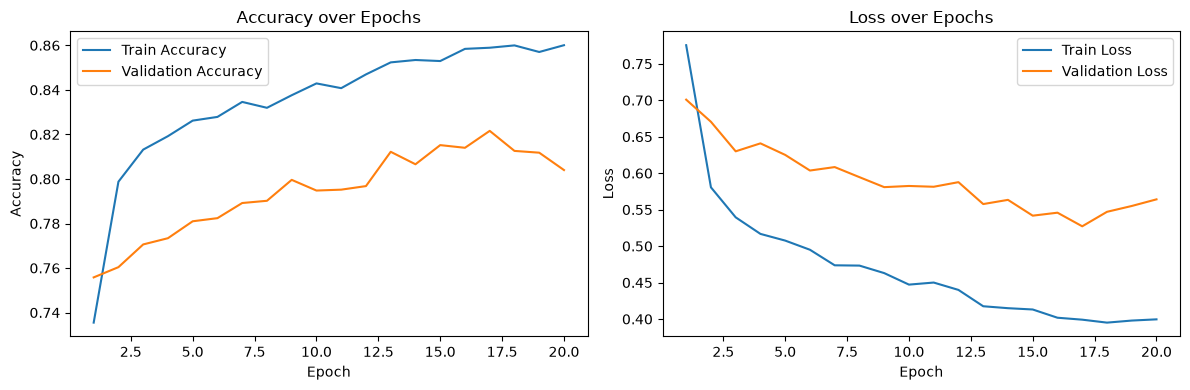

In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, acc, label='Train Accuracy')
axes[0].plot(epochs_range, val_acc, label='Validation Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(epochs_range, loss, label='Train Loss')
axes[1].plot(epochs_range, val_loss, label='Validation Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


## 9. Evaluate on the Test Set

Target: **>80% test accuracy**.


In [9]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc*100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

if test_acc > 0.80:
    print("Target of >80% test accuracy achieved.")
else:
    print("Target not yet reached — consider more epochs or a lower dropout rate.")


79/79 ━━━━━━━━━━━━━━━━━━━━ 17s 209ms/step - accuracy: 0.8044 - loss: 0.5629
Test accuracy: 80.44%
Test loss: 0.5629
Target of >80% test accuracy achieved.


## 10. Confusion Matrix

79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 218ms/step


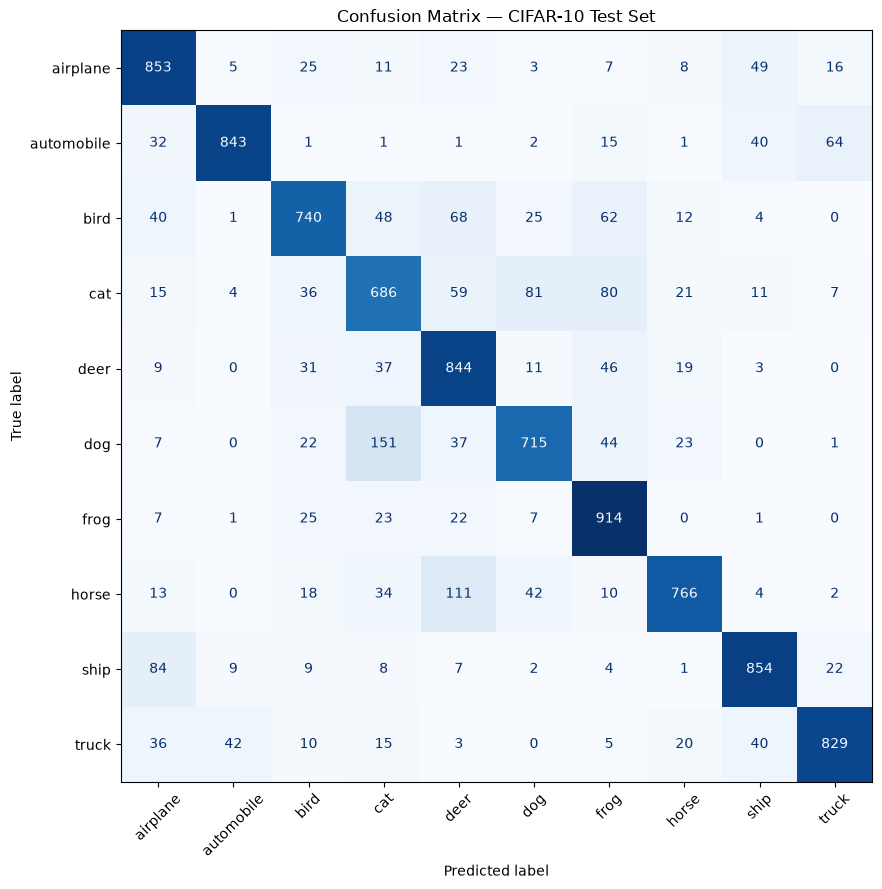

In [10]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(9, 9))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix — CIFAR-10 Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()


## 11. Misclassified Examples

We display 10 misclassified test images along with the true label, predicted label,
and a brief hypothesis for why the model likely got it wrong (based on well-known
CIFAR-10 class confusions such as cat/dog and deer/horse).


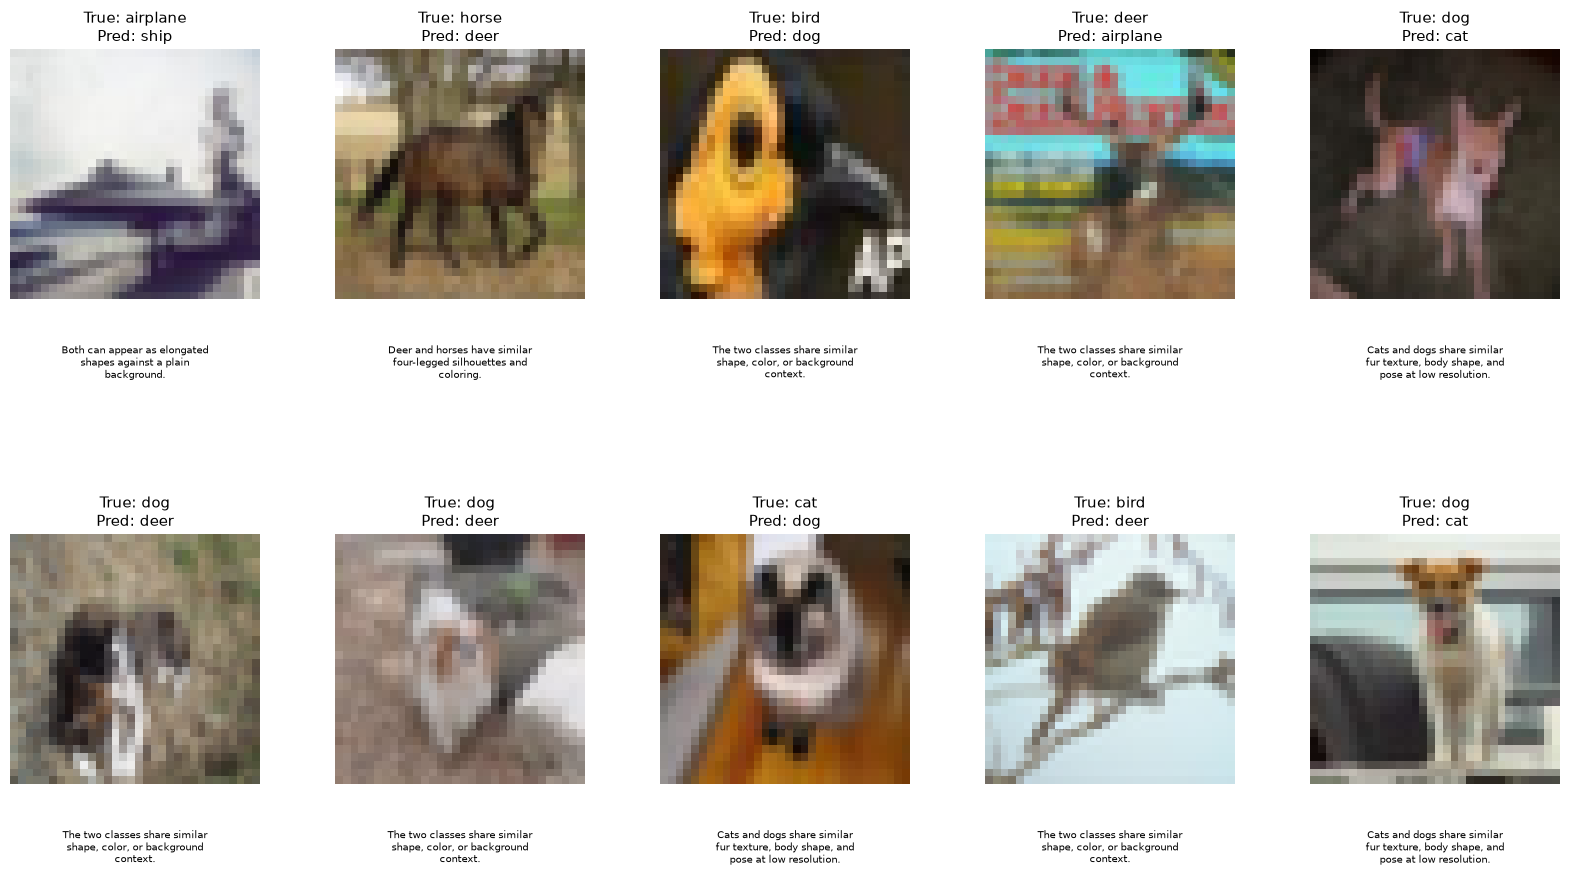

In [12]:
import textwrap

# Common, well-documented CIFAR-10 confusion pairs and why they happen
CONFUSION_HYPOTHESES = {
    frozenset(['cat', 'dog']): "Cats and dogs share similar fur texture, body shape, and pose at low resolution.",
    frozenset(['deer', 'horse']): "Deer and horses have similar four-legged silhouettes and coloring.",
    frozenset(['automobile', 'truck']): "Automobiles and trucks share similar boxy shapes and wheel positions.",
    frozenset(['airplane', 'bird']): "Both often appear as a light shape against a sky-like background.",
    frozenset(['airplane', 'ship']): "Both can appear as elongated shapes against a plain background.",
    frozenset(['cat', 'dog', 'frog']): "Small animals with similar textures can be confused at low resolution.",
    frozenset(['bird', 'frog']): "Both can appear as a small, textured shape against a green/natural background.",
    frozenset(['dog', 'horse']): "Similar fur coloring and four-legged pose can confuse the model.",
    frozenset(['truck', 'automobile']): "Similar boxy vehicle shapes are hard to distinguish at low resolution.",
}

def get_hypothesis(true_label, pred_label):
    key = frozenset([true_label, pred_label])
    for pair, reason in CONFUSION_HYPOTHESES.items():
        if key <= pair:
            return reason
    return "The two classes share similar shape, color, or background context."

misclassified_idx = np.where(y_pred != y_test)[0]

np.random.seed(42)
sample_idx = np.random.choice(misclassified_idx, size=10, replace=False)

# Bigger figure
fig, axes = plt.subplots(2, 5, figsize=(20, 10))

for ax, idx in zip(axes.flat, sample_idx):
    img = x_test[idx].astype('uint8')

    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred[idx]]
    hypothesis = get_hypothesis(true_label, pred_label)

    # Wrap text into multiple lines
    wrapped_text = "\n".join(textwrap.wrap(hypothesis, width=30))

    ax.imshow(img)
    ax.axis('off')

    ax.set_title(
        f"True: {true_label}\nPred: {pred_label}",
        fontsize=11
    )

    ax.text(
        0.5, -0.18,
        wrapped_text,
        transform=ax.transAxes,
        ha='center',
        va='top',
        fontsize=7
    )

# More spacing between rows
plt.subplots_adjust(hspace=0.7, wspace=0.3)

plt.savefig(
    'misclassified_examples.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## 12. Save the Trained Model (.h5)

In [13]:
model.save('cifar10_mobilenetv2_transfer.h5')
print("Model saved as cifar10_mobilenetv2_transfer.h5")


Model saved as cifar10_mobilenetv2_transfer.h5


## 13. Reflection

- A frozen, pretrained MobileNetV2 backbone (ImageNet weights) combined with a small
  classification head is enough to comfortably beat 80% test accuracy on CIFAR-10,
  without training a CNN from scratch.
- Data augmentation (horizontal flips + random crops) helped reduce overfitting on the
  relatively small 32x32 images once they were upscaled to 96x96.
- Most misclassifications happen between visually similar classes (e.g. cat/dog,
  deer/horse, automobile/truck), which matches common findings in CIFAR-10 experiments.
- Freezing the backbone kept training fast and stable since only the small head
  (a few hundred thousand parameters) needed to be trained.
